# Examen Final — Bienestar Mundial
## Nombre del estudiante: **Johel Chinchilla Oviedo**

**Individual y asíncrono · 180 minutos**

Complete únicamente las celdas marcadas como `TODO`, ejecute en orden y conserve las salidas que sustentan su bitácora.

**Cómo leer las consignas:** cada parte indica qué debe quedar visible al terminar. Esas indicaciones describen el producto a entregar, no una respuesta modelo.

## Instrucciones de trabajo y entrega

### Antes de comenzar

1. Guarde una copia como `Apellido_Nombre_Examen_Final.ipynb`.
2. Mantenga `bienestar_mundial_2023.csv` en la misma carpeta y no lo modifique.
3. Ejecute el notebook de arriba hacia abajo y responda solamente las celdas `TODO`.
4. Entregue un único notebook con código, salidas, tres entradas de bitácora y dos lecturas de gráficos.

### Condiciones

- Use únicamente Python, Pandas y Matplotlib trabajados en el curso.
- No use Internet, API ni fuentes externas; el análisis debe ser reproducible con el CSV entregado.
- Para la dispersión, use `pib_per_capita` y construya `df_limpio` solo para excluir sus valores faltantes. No altere `df` ni sustituya nulos por cero.
- En la Parte 2, la función debe recorrer la lista de diccionarios; no utilice `df` global dentro de ella.
- En la Parte 3, use una lista de regiones con `isin(...)`, un filtro compuesto, `groupby(...).agg(...)` con agregaciones nombradas y `nlargest(5, 'puntuacion_bienestar')`.
- Se califican decisiones justificadas y evidencias visibles; no se requiere una redacción idéntica a otra persona.

### Bitácora y entrega

Complete las tres bitácoras del notebook: limpieza, decisión analítica y cierre. Cada afirmación debe señalar el cálculo, tabla o gráfico que la respalda. Complete también una lectura para las barras y otra para la dispersión. Ningún gráfico demuestra causalidad por sí solo.

Antes de entregar, compruebe que el notebook corre desde el inicio, que el CSV sigue sin cambios, que `df` no fue modificado durante la limpieza y que los gráficos tienen títulos y ejes legibles.

### Tipos de TODO

- **TODO CÓDIGO:** escriba y ejecute Python en la celda de código inmediatamente siguiente o indicada.
- **TODO RESPUESTA ESCRITA:** reemplace el texto de esa celda Markdown con su respuesta.
- **TODO BITÁCORA:** reemplace el texto de esa celda Markdown con una reflexión respaldada por salidas del notebook.
- **TODO INTERPRETACIÓN:** reemplace el texto de esa celda Markdown con la lectura del gráfico indicado.

## 1. Carga, exploración y calidad de datos

El archivo contiene indicadores de bienestar por país y región. No modifique el CSV ni reemplace valores faltantes por cero.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('bienestar_mundial_2023.csv')
df.head(10)

,pais,region,puntuacion_bienestar,pib_per_capita,apoyo_social,esperanza_vida_saludable,libertad_decision,generosidad,percepcion_corrupcion
0,Finland,Europa Occidental,7.804,1.888,1.585,0.535,0.772,0.126,0.535
1,Denmark,Europa Occidental,7.586,1.949,1.548,0.537,0.734,0.208,0.525
2,Germany,Europa Occidental,6.892,1.919,1.401,0.539,0.618,0.153,0.365
3,Spain,Europa Occidental,6.436,1.798,1.491,0.567,0.533,0.101,0.157
4,Costa Rica,America Latina y el Caribe,6.609,1.587,1.340,0.503,0.683,0.099,0.116
5,Uruguay,America Latina y el Caribe,6.494,1.617,1.445,0.435,0.683,0.102,0.254
6,Chile,America Latina y el Caribe,6.334,1.645,1.384,0.511,0.546,0.131,0.076
7,Brazil,America Latina y el Caribe,6.125,NaN,1.250,0.387,0.558,0.131,0.137
8,Czechia,Europa Central y Oriental,6.845,1.823,1.544,0.477,0.693,0.158,0.050
9,Lithuania,Europa Central y Oriental,6.763,1.808,1.511,0.432,0.487,0.059,0.089


**Respuesta.** La *entrada* es el archivo `bienestar_mundial_2023.csv`, con 40 países descritos por 9 variables (identificación, región y siete indicadores de bienestar). El *proceso* consiste en explorar y limpiar los datos con Pandas, calcular promedios y agrupaciones, construir una función propia sobre una lista de diccionarios y filtrar/comparar regiones. La *salida* son tablas resumen, un ranking de los cinco países con mayor puntuación y dos gráficos (barras y dispersión) con su interpretación escrita.

- `pais`: nombre del país evaluado en el estudio (unidad de observación).
- `region`: agrupación geográfica/cultural a la que pertenece cada país (10 regiones en la muestra).
- `puntuacion_bienestar`: indicador compuesto de bienestar subjetivo reportado por la población, en una escala aproximada de 0 a 8.
- `pib_per_capita`: variable relacionada con el producto interno bruto por habitante, expresada en la misma escala logarítmica que el resto de los indicadores del estudio; tiene 2 valores faltantes en la muestra.

**TODO CÓDIGO 1.2 — Exploración y limpieza.** Muestre `shape`, `dtypes`, `info()` y nulos por columna. Muestre las filas con nulos y cree `df_limpio` excluyendo nulos únicamente en `pib_per_capita`, que se utilizará obligatoriamente en la dispersión de la Parte 4. Mantenga `df` sin modificar.

**Resultado visible esperado:** salidas para los cuatro comandos de exploración, una tabla con las filas que tienen nulos y la creación de `df_limpio`. Muestre también cuántas filas conserva `df_limpio`; no necesita modificar ni volver a guardar el CSV.

In [2]:
print('shape:', df.shape)
print()
print('dtypes:')
print(df.dtypes)
print()
df.info()
print()
print('Nulos por columna:')
print(df.isnull().sum())

# Filas con nulos
df[df.isnull().any(axis=1)]

# df_limpio: excluye únicamente los nulos de pib_per_capita; df queda intacto
df_limpio = df.dropna(subset=['pib_per_capita'])
print(f"df_limpio conserva {df_limpio.shape[0]} filas de {df.shape[0]} originales en df.")

shape: (40, 9)

dtypes:
pais                            str
region                          str
puntuacion_bienestar        float64
pib_per_capita              float64
apoyo_social                float64
esperanza_vida_saludable    float64
libertad_decision           float64
generosidad                 float64
percepcion_corrupcion       float64
dtype: object

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pais                      40 non-null     str    
 1   region                    40 non-null     str    
 2   puntuacion_bienestar      40 non-null     float64
 3   pib_per_capita            38 non-null     float64
 4   apoyo_social              40 non-null     float64
 5   esperanza_vida_saludable  40 non-null     float64
 6   libertad_decision         40 non-null     float64
 7   generosidad               40 non-null     floa

,pais,region,puntuacion_bienestar,pib_per_capita,apoyo_social,esperanza_vida_saludable,libertad_decision,generosidad,percepcion_corrupcion
7,Brazil,America Latina y el Caribe,6.125,NaN,1.250,0.387,0.558,0.131,0.137
30,Morocco,Oriente Medio y Norte de Africa,4.903,NaN,0.535,0.337,0.540,0.013,0.085


df_limpio conserva 38 filas de 40 originales en df.


**Respuesta.** Solo la columna `pib_per_capita` tiene valores nulos: 2 de 40 filas (Brazil y Morocco), como muestran `df.isnull().sum()` y la tabla de filas con nulos de la celda anterior. `df_limpio` se construyó con `df.dropna(subset=['pib_per_capita'])`, que excluye únicamente esas 2 filas y conserva 38 de las 40 filas originales, sin modificar `df` ni reemplazar los nulos por cero. Esta decisión afecta directamente la dispersión de la Parte 4: Brazil y Morocco no tendrán coordenada en el eje `pib_per_capita` y quedarán fuera de ese gráfico, aunque siguen presentes en el resto de los análisis basados en `df` (por ejemplo, `df_region` y `top_5`).

## 2. Python base: datos y función

**TODO CÓDIGO 2.1.** Convierta `df` en `registros`. Con un ciclo y una condición, cuente países con `puntuacion_bienestar` mayor o igual que 6.0.

**TODO CÓDIGO 2.2.** Defina `resumen_region(registros, region)`. Debe recorrer `registros` con un `for`, usar una condición sobre `region`, no depender de `df` global y devolver `region`, `cantidad_paises` y `promedio_bienestar`. Si no existe la región, devuelva `None`. Pruébela con una región existente y una inexistente; explique el segundo resultado.

**Resultado visible esperado:** una variable llamada `registros`, un conteo numérico impreso y dos pruebas de la función: una debe mostrar un diccionario y la otra debe mostrar `None`, acompañada de una explicación breve.

In [3]:
# Lista de diccionarios a partir de df
registros = df.to_dict('records')

# Ciclo + condición: países con puntuacion_bienestar >= 6.0
contador = 0
for r in registros:
    if r['puntuacion_bienestar'] >= 6.0:
        contador += 1
print(f'Países con puntuacion_bienestar >= 6.0: {contador}')


def resumen_region(registros, region):
    """Recorre `registros` (lista de diccionarios) sin usar df global."""
    cantidad_paises = 0
    suma_bienestar = 0.0
    for r in registros:
        if r['region'] == region:
            cantidad_paises += 1
            suma_bienestar += r['puntuacion_bienestar']
    if cantidad_paises == 0:
        return None
    return {
        'region': region,
        'cantidad_paises': cantidad_paises,
        'promedio_bienestar': round(suma_bienestar / cantidad_paises, 3),
    }


prueba_existente = resumen_region(registros, 'America Latina y el Caribe')
prueba_inexistente = resumen_region(registros, 'Antartida')
print('Región existente ->', prueba_existente)
print('Región inexistente ->', prueba_inexistente)
print('Explicación: "Antartida" no aparece en la columna region de ningún registro, por lo que\n'
      'cantidad_paises nunca se incrementa dentro del for y la función devuelve None por la guarda\n'
      'if cantidad_paises == 0, en vez de lanzar un error o dividir por cero.')

Países con puntuacion_bienestar >= 6.0: 23
Región existente -> {'region': 'America Latina y el Caribe', 'cantidad_paises': 4, 'promedio_bienestar': 6.39}
Región inexistente -> None
Explicación: "Antartida" no aparece en la columna region de ningún registro, por lo que
cantidad_paises nunca se incrementa dentro del for y la función devuelve None por la guarda
if cantidad_paises == 0, en vez de lanzar un error o dividir por cero.


## 3. Análisis integrado con Pandas

**TODO CÓDIGO 3.1.** Elija una región de la muestra y plantee una pregunta comparativa sobre bienestar. Justifique la elección con una observación de la exploración.

**TODO CÓDIGO 3.2.** Calcule el promedio de `puntuacion_bienestar` y cree `diferencia_promedio` sin reemplazar `df`. Cree un filtro de la región elegida y construya un resumen por región con `groupby(...).agg(...)`, usando agregaciones nombradas para promedio de bienestar y cantidad de países, ordenado de mayor a menor.

**TODO CÓDIGO 3.3 — Filtro tipo Semana 13.** Defina una lista llamada `regiones_comparadas` con la región elegida y una segunda región de la muestra. Cree `df_comparacion` usando `isin(regiones_comparadas)` y la condición de puntuación mayor o igual al promedio de la muestra. Muestre el resultado y conserve solo las columnas necesarias para comparar país, región y puntuación.

**TODO CÓDIGO 3.4.** Use `nlargest(5, 'puntuacion_bienestar')` para mostrar los cinco países con mayor puntuación, iniciando por el más alto. Responda la pregunta de 3.1 con al menos una cifra verificable.

**Resultado visible esperado:** el promedio de la muestra, una tabla de la región elegida, una tabla `df_comparacion` creada con `isin(...)`, un resumen de todas las regiones y un ranking de cinco filas. La respuesta escrita debe señalar una cifra de esas salidas.

In [4]:
# 3.1 Región elegida y pregunta comparativa
# Elijo 'America Latina y el Caribe' porque en la exploración de 1.2 aparece en el rango medio de la
# muestra y comparte dos filas con nulos en pib_per_capita, lo que la hace interesante para comparar.
# Pregunta: ¿la puntuación de bienestar promedio de America Latina y el Caribe difiere de la de
# Europa Occidental, la región líder de la muestra?

# 3.2 Promedio muestral, diferencia_promedio, filtro de región y resumen por región
promedio_muestra = df['puntuacion_bienestar'].mean()
print(f'promedio_muestra: {promedio_muestra:.3f}')

region_elegida = 'America Latina y el Caribe'
df_region = df[df['region'] == region_elegida]
promedio_region = df_region['puntuacion_bienestar'].mean()
diferencia_promedio = promedio_region - promedio_muestra
print(f'promedio de {region_elegida}: {promedio_region:.3f}')
print(f'diferencia_promedio: {diferencia_promedio:.3f}')
df_region

resumen_por_region = df.groupby('region').agg(
    promedio_bienestar=('puntuacion_bienestar', 'mean'),
    cantidad_paises=('pais', 'count'),
).sort_values('promedio_bienestar', ascending=False)
resumen_por_region

# 3.3 Filtro tipo Semana 13: isin(...) + condición compuesta
regiones_comparadas = ['America Latina y el Caribe', 'Europa Occidental']
df_comparacion = df[
    df['region'].isin(regiones_comparadas) & (df['puntuacion_bienestar'] >= promedio_muestra)
][['pais', 'region', 'puntuacion_bienestar']]
df_comparacion

# 3.4 Top 5 con nlargest y respuesta a la pregunta de 3.1
top_5 = df.nlargest(5, 'puntuacion_bienestar')
print(top_5[['pais', 'region', 'puntuacion_bienestar']])
print()
print(f'Respuesta 3.1: Europa Occidental promedia {resumen_por_region.loc["Europa Occidental", "promedio_bienestar"]:.3f} \n'
      f'frente a {promedio_region:.3f} de America Latina y el Caribe (diferencia_promedio = {diferencia_promedio:.3f}); \n'
      'sí existe una diferencia, aunque ambas regiones superan el promedio_muestra.')


promedio_muestra: 6.043
promedio de America Latina y el Caribe: 6.390
diferencia_promedio: 0.347


,pais,region,puntuacion_bienestar,pib_per_capita
4,Costa Rica,America Latina y el Caribe,6.609,1.587
5,Uruguay,America Latina y el Caribe,6.494,1.617
6,Chile,America Latina y el Caribe,6.334,1.645
7,Brazil,America Latina y el Caribe,6.125,NaN


,promedio_bienestar,cantidad_paises
region,,
Europa Occidental,7.180,4
Norteamerica y ANZ,7.018,4
Europa Central y Oriental,6.614,4
America Latina y el Caribe,6.390,4
Asia Sudoriental,6.051,4
Asia Oriental,5.934,4
Comunidad de Estados Independientes,5.828,4
Oriente Medio y Norte de Africa,5.752,4
Africa Subsahariana,5.067,4


,pais,region,puntuacion_bienestar
0,Finland,Europa Occidental,7.804
1,Denmark,Europa Occidental,7.586
2,Germany,Europa Occidental,6.892
3,Spain,Europa Occidental,6.436
4,Costa Rica,America Latina y el Caribe,6.609
5,Uruguay,America Latina y el Caribe,6.494
6,Chile,America Latina y el Caribe,6.334
7,Brazil,America Latina y el Caribe,6.125


           pais                           region  puntuacion_bienestar
0       Finland                Europa Occidental                 7.804
1       Denmark                Europa Occidental                 7.586
28       Israel  Oriente Medio y Norte de Africa                 7.473
12  New Zealand               Norteamerica y ANZ                 7.123
13    Australia               Norteamerica y ANZ                 7.095

Respuesta 3.1: Europa Occidental promedia 7.179 
frente a 6.390 de America Latina y el Caribe (diferencia_promedio = 0.347); 
sí existe una diferencia, aunque ambas regiones superan el promedio_muestra.


**Respuesta.** Región elegida: **America Latina y el Caribe**. Pregunta comparativa: ¿el bienestar promedio de esta región difiere del de Europa Occidental, la región líder de la muestra? El promedio de America Latina y el Caribe es **6.390**, frente a un `promedio_muestra` de **6.043** (`diferencia_promedio` = **0.347**), es decir, la región supera ligeramente la media general pero queda 0.789 puntos por debajo de Europa Occidental (7.180). `df_comparacion`, construido con `isin(['America Latina y el Caribe','Europa Occidental'])` y la condición de puntuación mayor o igual al promedio muestral, confirma que los 4 países de cada región superan ese umbral, mostrando que ambas están por encima de la media aunque con brechas distintas. El `resumen_por_region` (groupby.agg) ubica a Europa Occidental primera (7.180) y a America Latina y el Caribe en el cuarto lugar de 10 regiones (6.390), y el `top_5` (nlargest) confirma que ningún país de America Latina y el Caribe entra al grupo líder, cuyo mínimo es 7.095 (Australia). En conjunto, las tres salidas respaldan que sí existe una diferencia consistente entre ambas regiones.

## 4. Visualización e interpretación

**TODO CÓDIGO 4.1.** Cree barras horizontales para el top 5.

**TODO CÓDIGO 4.2.** Cree una dispersión de `pib_per_capita` frente a `puntuacion_bienestar` con `df_limpio`. Ambos gráficos deben incluir título, ejes y tamaño legible.

Justifique brevemente por qué barras y dispersión son adecuadas para estos datos transversales. Ningún gráfico demuestra causalidad.

**Resultado visible esperado:** dos gráficos separados y legibles: uno de barras con cinco categorías y una dispersión construida con `df_limpio`. Cada uno debe tener título y dos ejes identificados.

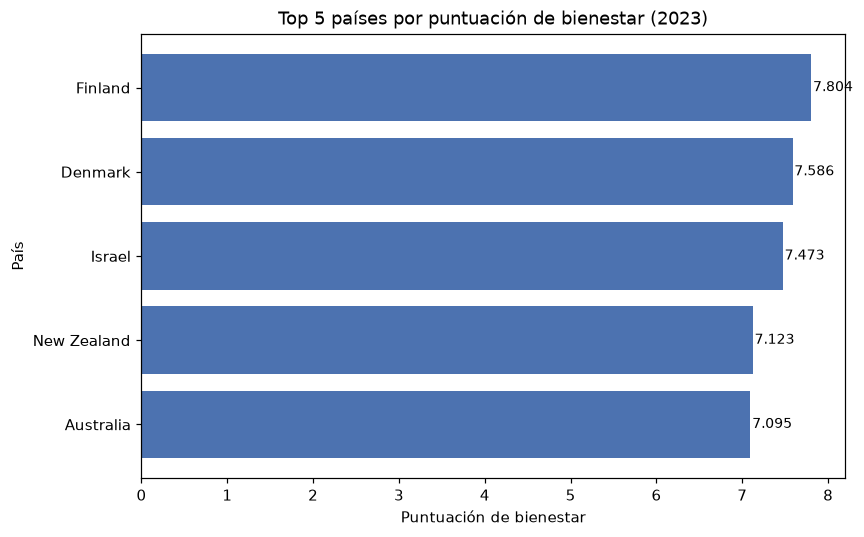

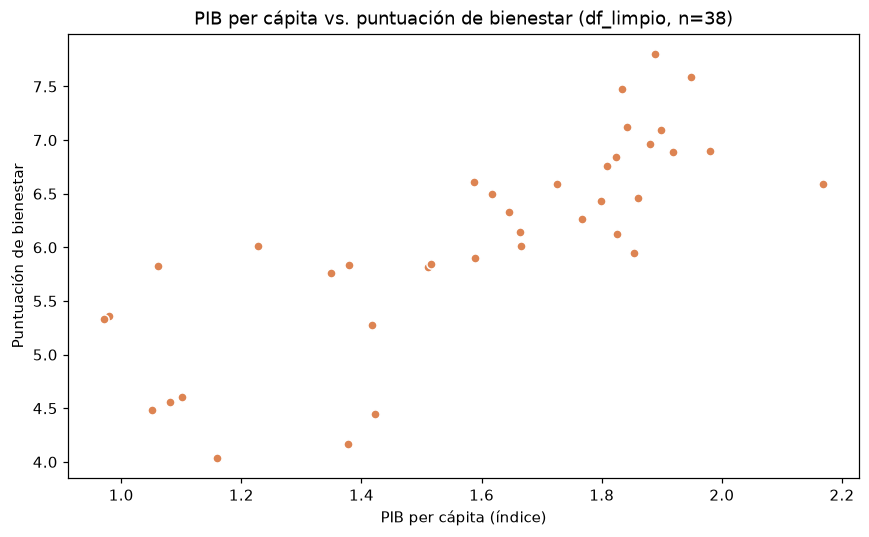

In [5]:
# 4.1 Barras horizontales para el top 5
orden = top_5.sort_values('puntuacion_bienestar')
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(orden['pais'], orden['puntuacion_bienestar'], color='#4C72B0')
ax.set_xlabel('Puntuación de bienestar')
ax.set_ylabel('País')
ax.set_title('Top 5 países por puntuación de bienestar (2023)')
for y, v in enumerate(orden['puntuacion_bienestar']):
    ax.text(v + 0.02, y, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

# 4.2 Dispersión pib_per_capita vs. puntuacion_bienestar con df_limpio
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_limpio['pib_per_capita'], df_limpio['puntuacion_bienestar'], color='#DD8452', edgecolor='white')
ax.set_xlabel('PIB per cápita (índice)')
ax.set_ylabel('Puntuación de bienestar')
ax.set_title(f'PIB per cápita vs. puntuación de bienestar (df_limpio, n={len(df_limpio)})')
plt.tight_layout()
plt.show()

# Justificación: ambos datos son transversales (un valor por país en 2023), sin componente temporal.
# Las barras ordenan y comparan un ranking pequeño y discreto (5 países); la dispersión muestra la
# relación entre dos variables continuas para todas las observaciones sin nulos. Ningún gráfico
# demuestra causalidad por sí solo.

**Respuesta.** El gráfico compara las cinco puntuaciones de bienestar más altas de la muestra: Finland encabeza con 7.804, y Australia cierra el grupo con 7.095, una diferencia de 0.709 puntos entre el primer y el quinto lugar. Esta lectura solo describe el orden y la magnitud del ranking; no explica por qué esos cinco países alcanzan las puntuaciones más altas.

**Respuesta.** En las 38 filas de `df_limpio` (sin los valores faltantes de `pib_per_capita`) se observa una asociación visual positiva: los países con mayor PIB per cápita tienden a ubicarse en puntuaciones de bienestar más altas, aunque hay excepciones con PIB per cápita similar y puntuaciones distintas. Esta lectura corresponde únicamente a las observaciones sin nulos en `pib_per_capita` (Brazil y Morocco quedaron excluidos) y no permite concluir que el ingreso cause el bienestar, ya que otras variables no graficadas podrían explicar la relación.

## 5. Bitácora de cierre e informe crítico

**Respuesta.**

1. 23 de los 40 países (57.5%) tienen `puntuacion_bienestar >= 6.0`, según el conteo con ciclo sobre `registros` de la Parte 2.
2. Europa Occidental lidera el bienestar promedio (7.179), 0.789 puntos por encima de America Latina y el Caribe (6.390), según `resumen_por_region` (`groupby().agg()`) de la Parte 3.
3. El `top_5` (`nlargest`) va de Finland (7.804) a Australia (7.095), una diferencia de 0.709 puntos dentro del grupo líder, visible en el gráfico de barras de la Parte 4.

**Limitación:** la muestra tiene solo 40 países (4 por región) y 2 valores faltantes en `pib_per_capita` (Brazil y Morocco), excluidos únicamente para la dispersión mediante `df_limpio`; esto limita cuánto se puede generalizar cualquier comparación regional.

**Conclusión no causal:** la asociación observada entre PIB per cápita y bienestar en la dispersión, junto con las diferencias regionales del resumen agrupado, sugieren una relación entre desarrollo económico y bienestar percibido, pero ningún gráfico ni tabla de este notebook permite afirmar que el ingreso *cause* el bienestar, dado el tamaño reducido de la muestra y la ausencia de variables de control.

## Lista de entrega

- [ ] Archivo nombrado `Apellido_Nombre_Examen_Final.ipynb`.
- [ ] Código ejecutado desde el inicio, sin errores.
- [ ] CSV sin modificar.
- [ ] Las tres entradas de bitácora y las dos lecturas incluyen evidencia visible.
- [ ] Gráficos, títulos, ejes e interpretaciones incluidos.